# Train Swin Transformer from AWS S3 records

This Colab notebook fine-tunes Microsoft's official **Swin-Tiny** image classifier for binary real-versus-synthetic image classification.

What it reads:

- Completion JSON files from the S3 **records/** folder.
- Image bytes referenced by each record's **clean_pair.input_path** and/or **augmented_pair.input_path**.
- The label at **source_metadata.binary_aigc_label**. The alternate spelling **binary_aijc_label** is accepted for compatibility.

What it never reads:

- No file or path from the **targets/** folder.
- No **target_path** value.

The JSON metadata is loaded into RAM to construct a reproducible train/validation manifest. Image bytes are streamed from S3 only when a DataLoader requests a sample; the image dataset is not copied to Colab storage.

Before running, select **Runtime → Change runtime type → GPU** in Colab.


## 1. Install dependencies and clone Microsoft's Swin repository

PyTorch and torchvision are supplied by Colab. This cell installs the remaining packages and clones the repository provided in the prompt.


In [ ]:
%pip install -q boto3 Pillow matplotlib pandas scikit-learn seaborn tqdm "timm>=0.9,<2"

from pathlib import Path
import subprocess

SWIN_REPO_URL = "https://github.com/microsoft/Swin-Transformer.git"
SWIN_REPO_DIR = Path("/content/Swin-Transformer")

if not (SWIN_REPO_DIR / "models" / "swin_transformer.py").exists():
    subprocess.run(
        ["git", "clone", "--depth", "1", SWIN_REPO_URL, str(SWIN_REPO_DIR)],
        check=True,
    )
else:
    print(f"Using existing repository at {SWIN_REPO_DIR}")

print("Swin source:", SWIN_REPO_DIR / "models" / "swin_transformer.py")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 140.0/140.0 kB 6.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.7/15.7 MB 108.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 90.2/90.2 kB 9.6 MB/s eta 0:00:00
Swin source: /content/Swin-Transformer/models/swin_transformer.py


## 2. Load AWS credentials safely

In Colab, add these names in the **Secrets** panel (key icon) and enable notebook access:

- AWS_ACCESS_KEY_ID
- AWS_SECRET_ACCESS_KEY
- AWS_DEFAULT_REGION
- AWS_SESSION_TOKEN only if you received temporary credentials

The cell also supports credentials already present in environment variables or in the normal boto3 credential chain. It never prints secret values.


In [ ]:
import os

try:
    from google.colab import userdata
except ImportError:
    userdata = None


def load_optional_colab_secret(name: str) -> bool:
    if os.environ.get(name):
        return True
    if userdata is None:
        return False
    try:
        value = userdata.get(name)
    except Exception:
        value = None
    if value:
        os.environ[name] = value
        return True
    return False


secret_names = [
    "AWS_ACCESS_KEY_ID",
    "AWS_SECRET_ACCESS_KEY",
    "AWS_DEFAULT_REGION"
]
loaded_names = [name for name in secret_names if load_optional_colab_secret(name)]

if not os.environ.get("AWS_DEFAULT_REGION"):
    os.environ["AWS_DEFAULT_REGION"] = "us-east-1"

print("AWS credential sources are configured.")
print("Loaded variable names:", loaded_names or "boto3 default credential chain")


AWS credential sources are configured.
Loaded variable names: ['AWS_ACCESS_KEY_ID', 'AWS_SECRET_ACCESS_KEY', 'AWS_DEFAULT_REGION']


## 3. Configuration

The defaults use the bucket and prefix from the attached notebook. **INPUT_VARIANT="both"** trains on clean and augmented inputs, which is useful when the classifier must handle transformed images.

Set **MAX_RECORDS** to a small integer only for a quick pipeline test. Leave it as **None** for full training.


In [ ]:
from pathlib import Path

# S3 dataset
S3_BUCKET = "tiktoktechjam"
S3_PREFIX = "autoencoder/training-003"
INPUT_VARIANT = "both"          # "clean", "augmented", or "both"
LABEL_KEYS = ("binary_aigc_label", "binary_aijc_label")
STRICT_RECORDS = True           # Fail instead of silently ignoring malformed records
MAX_RECORDS = None              # Example quick test: 200; full dataset: None
METADATA_WORKERS = 16

# Reproducible split
VALIDATION_FRACTION = 0.20
SEED = 42

# Swin-Tiny fine-tuning
IMAGE_SIZE = 224
BATCH_SIZE = 32
NUM_WORKERS = 4
NUM_EPOCHS = 60
EARLY_STOPPING_PATIENCE = 7
MIN_IMPROVEMENT = 1e-4
LEARNING_RATE = 3e-5
WEIGHT_DECAY = 0.05
MAX_GRAD_NORM = 1.0
USE_PRETRAINED = True
USE_MIXED_PRECISION = True

# Label convention from binary_aigc_label
CLASS_NAMES = {0: "real", 1: "synthetic"}

OUTPUT_DIR = Path("/content/swin_outputs")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

assert INPUT_VARIANT in {"clean", "augmented", "both"}
assert 0 < VALIDATION_FRACTION < 1
assert BATCH_SIZE >= 1
assert NUM_EPOCHS >= 1

print("Configuration ready.")


Configuration ready.


## 4. Connect to S3 and find every JSON record

The required AWS permissions are:

- s3:ListBucket for the selected records prefix.
- s3:GetObject for JSON records and referenced input images.

The notebook does not call ListBuckets and does not need access to unrelated buckets.


In [ ]:
import json
import random
import threading
from collections import Counter
from concurrent.futures import ThreadPoolExecutor, as_completed
from io import BytesIO
from urllib.parse import urlparse

import boto3
import numpy as np
import pandas as pd
import torch
from botocore.config import Config
from PIL import Image
from tqdm.auto import tqdm


def seed_everything(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


seed_everything(SEED)


def make_s3_client():
    return boto3.client(
        "s3",
        config=Config(
            retries={"max_attempts": 10, "mode": "adaptive"},
            max_pool_connections=max(32, METADATA_WORKERS + 2 * NUM_WORKERS),
        ),
    )


def read_s3_bytes(client, bucket: str, key: str) -> bytes:
    response = client.get_object(Bucket=bucket, Key=key)
    body = response["Body"]
    try:
        return body.read()
    finally:
        body.close()


def list_record_keys(client) -> list[str]:
    prefix = f"{S3_PREFIX.strip('/')}/records/"
    paginator = client.get_paginator("list_objects_v2")
    keys = []

    for page in paginator.paginate(Bucket=S3_BUCKET, Prefix=prefix):
        keys.extend(
            item["Key"]
            for item in page.get("Contents", [])
            if item["Key"].lower().endswith(".json")
        )

    return sorted(keys)


s3_test_client = make_s3_client()
record_keys = list_record_keys(s3_test_client)

if not record_keys:
    raise RuntimeError(
        f"No JSON records found at s3://{S3_BUCKET}/"
        f"{S3_PREFIX.strip('/')}/records/"
    )

print(f"Found {len(record_keys):,} JSON record files.")

if MAX_RECORDS is not None:
    if MAX_RECORDS < 1:
        raise ValueError("MAX_RECORDS must be None or a positive integer.")
    selection_rng = random.Random(SEED)
    selection_rng.shuffle(record_keys)
    record_keys = sorted(record_keys[:MAX_RECORDS])
    print(f"Quick-test limit active: using {len(record_keys):,} records.")


Found 9,436 JSON record files.


## 5. Pull the JSON records and build the input-only manifest

The record parser intentionally accesses only **input_path**. Even though the JSON may contain **target_path**, that field is never read.

All variants from one sample remain grouped at this stage so they can be assigned to the same split later.


In [ ]:
_thread_local = threading.local()


def thread_s3_client():
    if not hasattr(_thread_local, "s3_client"):
        _thread_local.s3_client = make_s3_client()
    return _thread_local.s3_client


def parse_s3_reference(reference: str, default_bucket: str) -> tuple[str, str]:
    if not isinstance(reference, str) or not reference.strip():
        raise ValueError("input_path is missing or empty")

    reference = reference.strip()
    if reference.startswith("s3://"):
        parsed = urlparse(reference)
        if not parsed.netloc or not parsed.path.lstrip("/"):
            raise ValueError(f"Invalid S3 URI: {reference}")
        return parsed.netloc, parsed.path.lstrip("/")

    return default_bucket, reference.lstrip("/")


def extract_binary_label(record: dict, record_key: str) -> tuple[int, str]:
    metadata = record.get("source_metadata")
    if not isinstance(metadata, dict):
        raise KeyError(f"{record_key}: source_metadata is missing")

    selected_key = next((key for key in LABEL_KEYS if key in metadata), None)
    if selected_key is None:
        raise KeyError(
            f"{record_key}: none of the label keys {LABEL_KEYS} were found "
            "inside source_metadata"
        )

    raw_label = metadata[selected_key]

    if isinstance(raw_label, bool):
        label = int(raw_label)
    elif isinstance(raw_label, (int, np.integer)):
        label = int(raw_label)
    elif isinstance(raw_label, float) and raw_label.is_integer():
        label = int(raw_label)
    elif isinstance(raw_label, str) and raw_label.strip() in {"0", "1"}:
        label = int(raw_label.strip())
    else:
        raise ValueError(
            f"{record_key}: {selected_key} must be binary 0 or 1; "
            f"received {raw_label!r}"
        )

    if label not in CLASS_NAMES:
        raise ValueError(
            f"{record_key}: {selected_key} must be 0 or 1; received {label}"
        )

    return label, selected_key


def parse_record(record_key: str, record: dict) -> dict:
    label, label_key = extract_binary_label(record, record_key)
    sample_id = str(record.get("sample_id") or Path(record_key).stem)

    variants = (
        ["clean", "augmented"]
        if INPUT_VARIANT == "both"
        else [INPUT_VARIANT]
    )
    images = []

    for variant in variants:
        pair_name = f"{variant}_pair"
        pair = record.get(pair_name)
        if not isinstance(pair, dict):
            raise KeyError(f"{record_key}: {pair_name} is missing")

        # Deliberately read input_path only. target_path is never accessed.
        input_reference = pair.get("input_path")
        image_bucket, image_key = parse_s3_reference(
            input_reference,
            default_bucket=S3_BUCKET,
        )
        images.append(
            {
                "bucket": image_bucket,
                "key": image_key,
                "variant": variant,
            }
        )

    metadata = record["source_metadata"]
    return {
        "sample_id": sample_id,
        "label": label,
        "label_key": label_key,
        "label_name_in_record": metadata.get("label_name"),
        "record_key": record_key,
        "images": images,
    }


def load_and_parse_record(record_key: str):
    try:
        client = thread_s3_client()
        payload = json.loads(
            read_s3_bytes(client, S3_BUCKET, record_key).decode("utf-8")
        )
        return parse_record(record_key, payload), None
    except Exception as exc:
        return None, f"{record_key}: {type(exc).__name__}: {exc}"


parsed_records = []
record_errors = []

with ThreadPoolExecutor(max_workers=METADATA_WORKERS) as executor:
    future_to_key = {
        executor.submit(load_and_parse_record, key): key
        for key in record_keys
    }
    for future in tqdm(
        as_completed(future_to_key),
        total=len(future_to_key),
        desc="Reading records/*.json",
    ):
        parsed, error = future.result()
        if error is None:
            parsed_records.append(parsed)
        else:
            record_errors.append(error)

if record_errors:
    print(f"Malformed or inaccessible records: {len(record_errors):,}")
    for message in record_errors[:10]:
        print(" -", message)
    if STRICT_RECORDS:
        raise RuntimeError(
            "Record validation failed. Fix the records above or set "
            "STRICT_RECORDS=False to skip them explicitly."
        )

if not parsed_records:
    raise RuntimeError("No valid records remain after parsing.")

# Group duplicate record entries by sample_id so a sample can never cross splits.
sample_map = {}
for parsed in parsed_records:
    sample_id = parsed["sample_id"]
    if sample_id not in sample_map:
        sample_map[sample_id] = {
            "sample_id": sample_id,
            "label": parsed["label"],
            "record_keys": [parsed["record_key"]],
            "images": list(parsed["images"]),
        }
        continue

    existing = sample_map[sample_id]
    if existing["label"] != parsed["label"]:
        raise ValueError(
            f"Conflicting labels found for sample_id {sample_id}: "
            f"{existing['label']} and {parsed['label']}"
        )
    existing["record_keys"].append(parsed["record_key"])
    existing["images"].extend(parsed["images"])

# Remove duplicate image references within a sample.
for sample in sample_map.values():
    unique_images = {}
    for image_ref in sample["images"]:
        unique_images[
            (image_ref["bucket"], image_ref["key"], image_ref["variant"])
        ] = image_ref
    sample["images"] = list(unique_images.values())

sample_groups = sorted(sample_map.values(), key=lambda item: item["sample_id"])
label_counts = Counter(sample["label"] for sample in sample_groups)
image_count = sum(len(sample["images"]) for sample in sample_groups)

manifest_summary = pd.DataFrame(
    [
        {
            "label": label,
            "class": CLASS_NAMES[label],
            "unique_samples": label_counts.get(label, 0),
            "streamed_image_references": sum(
                len(sample["images"])
                for sample in sample_groups
                if sample["label"] == label
            ),
        }
        for label in sorted(CLASS_NAMES)
    ]
)

print(f"Valid JSON records loaded: {len(parsed_records):,}")
print(f"Unique sample IDs: {len(sample_groups):,}")
print(f"Input images per full epoch: {image_count:,}")
print("Target images referenced: 0")
display(manifest_summary)


Reading records/*.json:   0%|          | 0/9436 [00:00<?, ?it/s]

Valid JSON records loaded: 9,436
Unique sample IDs: 9,436
Input images per full epoch: 18,872
Target images referenced: 0


,label,class,unique_samples,streamed_image_references
0,0,real,3179,6358
1,1,synthetic,6257,12514


## 6. Create a stratified, leakage-safe train/validation split

The split happens at the **sample_id** level. Clean and augmented versions of the same underlying image therefore cannot appear in both training and validation.

After splitting, each selected input variant becomes one dataset row.


In [ ]:
from sklearn.model_selection import train_test_split


def expand_sample_groups(groups: list[dict]) -> list[dict]:
    rows = []
    for sample in groups:
        for image_ref in sample["images"]:
            rows.append(
                {
                    "sample_id": sample["sample_id"],
                    "label": sample["label"],
                    "bucket": image_ref["bucket"],
                    "key": image_ref["key"],
                    "variant": image_ref["variant"],
                }
            )
    return rows


if set(label_counts) != {0, 1}:
    raise ValueError(
        "Binary training requires both label 0 and label 1. "
        f"Observed labels: {dict(label_counts)}"
    )

if min(label_counts.values()) < 2:
    raise ValueError(
        "Each class needs at least two unique samples for a stratified split. "
        f"Observed: {dict(label_counts)}"
    )

group_labels = [sample["label"] for sample in sample_groups]
train_groups, val_groups = train_test_split(
    sample_groups,
    test_size=VALIDATION_FRACTION,
    random_state=SEED,
    shuffle=True,
    stratify=group_labels,
)

train_sample_ids = {sample["sample_id"] for sample in train_groups}
val_sample_ids = {sample["sample_id"] for sample in val_groups}
assert train_sample_ids.isdisjoint(val_sample_ids)

train_rows = expand_sample_groups(train_groups)
val_rows = expand_sample_groups(val_groups)

split_summary = pd.DataFrame(
    [
        {
            "split": "train",
            "unique_samples": len(train_groups),
            "image_rows": len(train_rows),
            "real_rows": sum(row["label"] == 0 for row in train_rows),
            "synthetic_rows": sum(row["label"] == 1 for row in train_rows),
        },
        {
            "split": "validation",
            "unique_samples": len(val_groups),
            "image_rows": len(val_rows),
            "real_rows": sum(row["label"] == 0 for row in val_rows),
            "synthetic_rows": sum(row["label"] == 1 for row in val_rows),
        },
    ]
)

display(split_summary)
print("Train/validation sample-ID overlap:", 0)


,split,unique_samples,image_rows,real_rows,synthetic_rows
0,train,7548,15096,5086,10010
1,validation,1888,3776,1272,2504


Train/validation sample-ID overlap: 0


## 7. Define the S3 streaming image dataset

Each DataLoader worker creates its own S3 client. A requested image is downloaded into memory, decoded, transformed, and returned as a tensor. Nothing is written to a local dataset folder.

The validation transform is deterministic. The training transform adds only a horizontal flip so existing forensic signals are not hidden by aggressive augmentation.


In [ ]:
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms
from torchvision.transforms import InterpolationMode

IMAGENET_MEAN = (0.485, 0.456, 0.406)
IMAGENET_STD = (0.229, 0.224, 0.225)

train_transform = transforms.Compose(
    [
        transforms.Resize(
            (IMAGE_SIZE, IMAGE_SIZE),
            interpolation=InterpolationMode.BICUBIC,
            antialias=True,
        ),
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.ToTensor(),
        transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
    ]
)

validation_transform = transforms.Compose(
    [
        transforms.Resize(
            (IMAGE_SIZE, IMAGE_SIZE),
            interpolation=InterpolationMode.BICUBIC,
            antialias=True,
        ),
        transforms.ToTensor(),
        transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
    ]
)


class S3BinaryImageDataset(Dataset):
    """Map-style dataset whose image bytes are fetched from S3 on demand."""

    def __init__(self, rows: list[dict], transform) -> None:
        self.rows = list(rows)
        self.transform = transform
        self._client = None

    def __len__(self) -> int:
        return len(self.rows)

    def __getstate__(self):
        state = self.__dict__.copy()
        state["_client"] = None
        return state

    def _get_client(self):
        if self._client is None:
            self._client = make_s3_client()
        return self._client

    def __getitem__(self, index: int) -> dict:
        row = self.rows[index]
        try:
            image_bytes = read_s3_bytes(
                self._get_client(),
                row["bucket"],
                row["key"],
            )
            with Image.open(BytesIO(image_bytes)) as opened:
                image = opened.convert("RGB").copy()
            image_tensor = self.transform(image)
        except Exception as exc:
            raise RuntimeError(
                f"Could not stream s3://{row['bucket']}/{row['key']}: {exc}"
            ) from exc

        return {
            "image": image_tensor,
            "label": torch.tensor(row["label"], dtype=torch.long),
            "sample_id": row["sample_id"],
            "variant": row["variant"],
            "s3_key": row["key"],
        }


## 8. Create loaders and test one streamed batch

If S3 errors are difficult to diagnose, temporarily set **NUM_WORKERS=0**. On a typical Colab GPU, start with 2 workers and increase only if S3 remains the bottleneck.


/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


Streamed batch image shape: (32, 3, 224, 224)
Streamed labels: [1, 0, 1, 1, 1, 0, 1, 0]
Variants: ['clean', 'augmented', 'clean', 'clean', 'clean', 'augmented', 'clean', 'clean']


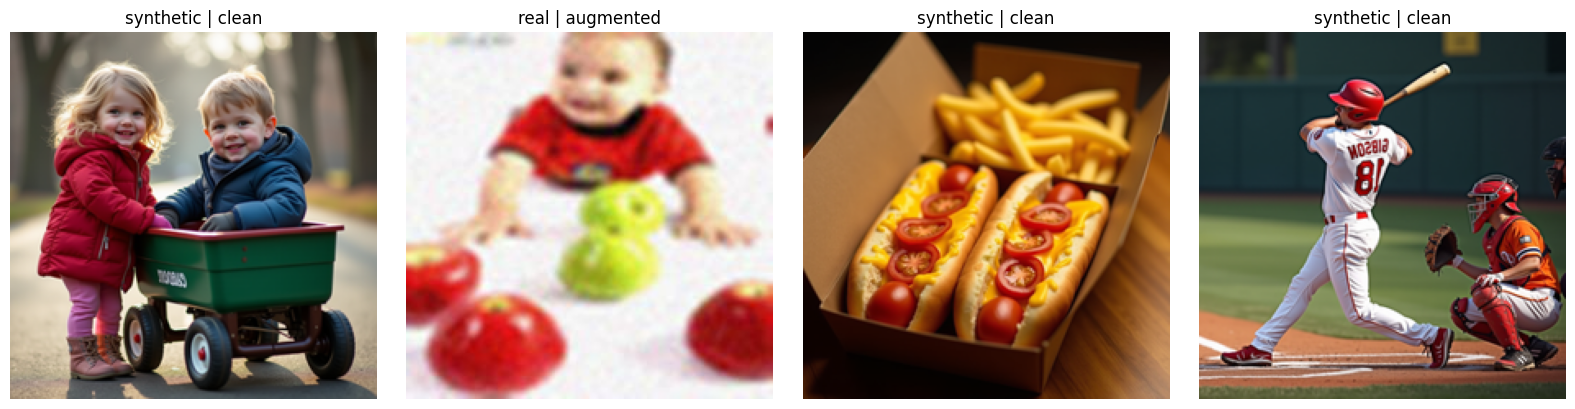

In [ ]:
import matplotlib.pyplot as plt

train_dataset = S3BinaryImageDataset(train_rows, train_transform)
val_dataset = S3BinaryImageDataset(val_rows, validation_transform)

loader_common = {
    "batch_size": BATCH_SIZE,
    "num_workers": NUM_WORKERS,
    "pin_memory": torch.cuda.is_available(),
}
if NUM_WORKERS > 0:
    loader_common.update(
        {
            "persistent_workers": True,
            "prefetch_factor": 2,
        }
    )

loader_generator = torch.Generator()
loader_generator.manual_seed(SEED)

train_loader = DataLoader(
    train_dataset,
    shuffle=True,
    generator=loader_generator,
    **loader_common,
)
val_loader = DataLoader(
    val_dataset,
    shuffle=False,
    **loader_common,
)

test_batch = next(iter(train_loader))
print("Streamed batch image shape:", tuple(test_batch["image"].shape))
print("Streamed labels:", test_batch["label"][:8].tolist())
print("Variants:", list(test_batch["variant"][:8]))
assert test_batch["image"].shape[1:] == (3, IMAGE_SIZE, IMAGE_SIZE)

mean = torch.tensor(IMAGENET_MEAN).view(3, 1, 1)
std = torch.tensor(IMAGENET_STD).view(3, 1, 1)
preview_count = min(4, test_batch["image"].shape[0])

figure, axes = plt.subplots(1, preview_count, figsize=(4 * preview_count, 4))
if preview_count == 1:
    axes = [axes]

for index in range(preview_count):
    image = (test_batch["image"][index].cpu() * std + mean).clamp(0, 1)
    axes[index].imshow(image.permute(1, 2, 0))
    label = int(test_batch["label"][index])
    axes[index].set_title(
        f"{CLASS_NAMES[label]} | {test_batch['variant'][index]}"
    )
    axes[index].axis("off")

plt.tight_layout()
plt.show()


## 9. Build Microsoft's official Swin-Tiny and load ImageNet weights

The model class is imported directly from the cloned Microsoft repository. The official ImageNet-1K Swin-Tiny checkpoint is loaded first; its 1,000-class head is then replaced with a two-class head.


In [ ]:
import importlib.util
import torch.nn as nn

SWIN_SOURCE_FILE = SWIN_REPO_DIR / "models" / "swin_transformer.py"
module_spec = importlib.util.spec_from_file_location(
    "microsoft_swin_transformer",
    SWIN_SOURCE_FILE,
)
if module_spec is None or module_spec.loader is None:
    raise ImportError(f"Could not import {SWIN_SOURCE_FILE}")

microsoft_swin = importlib.util.module_from_spec(module_spec)
module_spec.loader.exec_module(microsoft_swin)
SwinTransformer = microsoft_swin.SwinTransformer

OFFICIAL_SWIN_TINY_CHECKPOINT = (
    "https://github.com/SwinTransformer/storage/releases/download/"
    "v1.0.0/swin_tiny_patch4_window7_224.pth"
)


def build_swin_tiny(num_classes: int = 2, pretrained: bool = True):
    initial_classes = 1000 if pretrained else num_classes
    model = SwinTransformer(
        img_size=IMAGE_SIZE,
        patch_size=4,
        in_chans=3,
        num_classes=initial_classes,
        embed_dim=96,
        depths=[2, 2, 6, 2],
        num_heads=[3, 6, 12, 24],
        window_size=7,
        mlp_ratio=4.0,
        qkv_bias=True,
        qk_scale=None,
        drop_rate=0.0,
        attn_drop_rate=0.0,
        drop_path_rate=0.2,
        norm_layer=nn.LayerNorm,
        ape=False,
        patch_norm=True,
        use_checkpoint=False,
        fused_window_process=False,
    )

    if pretrained:
        checkpoint = torch.hub.load_state_dict_from_url(
            OFFICIAL_SWIN_TINY_CHECKPOINT,
            map_location="cpu",
            progress=True,
        )
        state_dict = checkpoint.get("model", checkpoint)
        incompatible = model.load_state_dict(state_dict, strict=True)
        if incompatible.missing_keys or incompatible.unexpected_keys:
            raise RuntimeError(
                "Official checkpoint did not match Swin-Tiny: "
                f"missing={incompatible.missing_keys}, "
                f"unexpected={incompatible.unexpected_keys}"
            )

        model.head = nn.Linear(model.num_features, num_classes)
        nn.init.trunc_normal_(model.head.weight, std=0.02)
        nn.init.zeros_(model.head.bias)

    return model


DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
if DEVICE.type != "cuda":
    print("WARNING: No GPU detected. Training will work but will be very slow.")

if torch.cuda.is_available():
    torch.backends.cudnn.benchmark = True
    torch.backends.cuda.matmul.allow_tf32 = True
    torch.backends.cudnn.allow_tf32 = True

model = build_swin_tiny(
    num_classes=len(CLASS_NAMES),
    pretrained=USE_PRETRAINED,
).to(DEVICE)

total_parameters = sum(parameter.numel() for parameter in model.parameters())
trainable_parameters = sum(
    parameter.numel()
    for parameter in model.parameters()
    if parameter.requires_grad
)

print("Device:", DEVICE)
print(f"Total parameters: {total_parameters:,}")
print(f"Trainable parameters: {trainable_parameters:,}")
print(model.head)


/usr/local/lib/python3.13/dist-packages/timm/models/layers/__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)
/usr/local/lib/python3.13/dist-packages/torch/functional.py:505: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at /pytorch/aten/src/ATen/native/TensorShape.cpp:4381.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


[Warning] Fused window process have not been installed. Please refer to get_started.md for installation.
Downloading: "https://github.com/SwinTransformer/storage/releases/download/v1.0.0/swin_tiny_patch4_window7_224.pth" to /root/.cache/torch/hub/checkpoints/swin_tiny_patch4_window7_224.pth


100%|██████████| 109M/109M [00:02<00:00, 44.7MB/s]


Device: cuda
Total parameters: 27,520,892
Trainable parameters: 27,520,892
Linear(in_features=768, out_features=2, bias=True)


## 10. Configure loss, optimizer, learning-rate reduction, and mixed precision

Class-weighted cross-entropy reduces bias if the training set is imbalanced. Mixed precision is enabled only on CUDA.


In [ ]:
import contextlib

train_label_array = np.array(
    [row["label"] for row in train_rows],
    dtype=np.int64,
)
train_class_counts = np.bincount(
    train_label_array,
    minlength=len(CLASS_NAMES),
)

if np.any(train_class_counts == 0):
    raise ValueError(
        f"Every class must appear in training. Counts: {train_class_counts}"
    )

class_weights = len(train_label_array) / (
    len(CLASS_NAMES) * train_class_counts
)
class_weight_tensor = torch.tensor(
    class_weights,
    dtype=torch.float32,
    device=DEVICE,
)

criterion = nn.CrossEntropyLoss(weight=class_weight_tensor)
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY,
)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.5,
    patience=2,
    min_lr=1e-7,
)

AMP_ENABLED = USE_MIXED_PRECISION and DEVICE.type == "cuda"

if hasattr(torch, "amp") and hasattr(torch.amp, "GradScaler"):
    scaler = torch.amp.GradScaler("cuda", enabled=AMP_ENABLED)

    def amp_context():
        return torch.amp.autocast(
            device_type="cuda",
            dtype=torch.float16,
            enabled=AMP_ENABLED,
        )
else:
    scaler = torch.cuda.amp.GradScaler(enabled=AMP_ENABLED)

    def amp_context():
        if AMP_ENABLED:
            return torch.cuda.amp.autocast(dtype=torch.float16)
        return contextlib.nullcontext()

print("Training class counts:", train_class_counts.tolist())
print("Loss class weights:", class_weights.round(4).tolist())
print("Mixed precision enabled:", AMP_ENABLED)


Training class counts: [5086, 10010]
Loss class weights: [1.4841, 0.754]
Mixed precision enabled: True


## 11. Training and validation functions

Validation reports:

- Cross-entropy loss
- Accuracy
- Precision for class 1
- Recall for class 1
- F1 for class 1
- ROC-AUC


In [ ]:
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)


def train_one_epoch(model, loader, optimizer, criterion) -> dict:
    model.train()
    loss_sum = 0.0
    correct = 0
    example_count = 0

    progress = tqdm(loader, desc="Training", leave=False)

    for batch in progress:
        images = batch["image"].to(
            DEVICE,
            non_blocking=True,
        )
        labels = batch["label"].to(
            DEVICE,
            non_blocking=True,
        )

        optimizer.zero_grad(set_to_none=True)

        with amp_context():
            logits = model(images)
            loss = criterion(logits, labels)

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            MAX_GRAD_NORM,
        )
        scaler.step(optimizer)
        scaler.update()

        batch_size = labels.size(0)
        loss_sum += loss.item() * batch_size
        correct += (logits.argmax(dim=1) == labels).sum().item()
        example_count += batch_size

        progress.set_postfix(
            loss=f"{loss_sum / example_count:.4f}",
            accuracy=f"{correct / example_count:.4f}",
        )

    return {
        "loss": loss_sum / example_count,
        "accuracy": correct / example_count,
    }


@torch.inference_mode()
def evaluate(model, loader, criterion):
    model.eval()
    loss_sum = 0.0
    example_count = 0
    all_labels = []
    all_probabilities = []
    all_sample_ids = []
    all_variants = []
    all_s3_keys = []

    progress = tqdm(loader, desc="Validating", leave=False)

    for batch in progress:
        images = batch["image"].to(
            DEVICE,
            non_blocking=True,
        )
        labels = batch["label"].to(
            DEVICE,
            non_blocking=True,
        )

        with amp_context():
            logits = model(images)
            loss = criterion(logits, labels)

        probabilities = torch.softmax(
            logits.float(),
            dim=1,
        )[:, 1]

        batch_size = labels.size(0)
        loss_sum += loss.item() * batch_size
        example_count += batch_size

        all_labels.extend(labels.cpu().tolist())
        all_probabilities.extend(probabilities.cpu().tolist())
        all_sample_ids.extend(list(batch["sample_id"]))
        all_variants.extend(list(batch["variant"]))
        all_s3_keys.extend(list(batch["s3_key"]))

    y_true = np.asarray(all_labels, dtype=np.int64)
    y_probability = np.asarray(all_probabilities, dtype=np.float64)
    y_pred = (y_probability >= 0.5).astype(np.int64)

    metrics = {
        "loss": loss_sum / example_count,
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(
            y_true,
            y_pred,
            pos_label=1,
            zero_division=0,
        ),
        "recall": recall_score(
            y_true,
            y_pred,
            pos_label=1,
            zero_division=0,
        ),
        "f1": f1_score(
            y_true,
            y_pred,
            pos_label=1,
            zero_division=0,
        ),
        "roc_auc": roc_auc_score(y_true, y_probability),
    }

    details = {
        "y_true": y_true,
        "y_probability": y_probability,
        "y_pred": y_pred,
        "sample_ids": all_sample_ids,
        "variants": all_variants,
        "s3_keys": all_s3_keys,
    }
    return metrics, details


## 12. Train, validate every epoch, save the best model, and stop early

The best checkpoint is selected by validation F1. Validation loss still controls learning-rate reduction. Training stops after the configured number of epochs without a meaningful F1 improvement.


In [ ]:
BEST_CHECKPOINT = OUTPUT_DIR / "best_swin_tiny_binary.pth"
HISTORY_CSV = OUTPUT_DIR / "training_history.csv"

history = []
best_validation_f1 = -float("inf")
epochs_without_improvement = 0

for epoch in range(1, NUM_EPOCHS + 1):
    current_lr = optimizer.param_groups[0]["lr"]
    print(
        f"\nEpoch {epoch}/{NUM_EPOCHS} "
        f"| learning rate {current_lr:.2e}"
    )

    train_metrics = train_one_epoch(
        model,
        train_loader,
        optimizer,
        criterion,
    )
    validation_metrics, _ = evaluate(
        model,
        val_loader,
        criterion,
    )
    scheduler.step(validation_metrics["loss"])

    epoch_record = {
        "epoch": epoch,
        "learning_rate": current_lr,
        "train_loss": float(train_metrics["loss"]),
        "train_accuracy": float(train_metrics["accuracy"]),
        "val_loss": float(validation_metrics["loss"]),
        "val_accuracy": float(validation_metrics["accuracy"]),
        "val_precision": float(validation_metrics["precision"]),
        "val_recall": float(validation_metrics["recall"]),
        "val_f1": float(validation_metrics["f1"]),
        "val_roc_auc": float(validation_metrics["roc_auc"]),
    }
    history.append(epoch_record)
    pd.DataFrame(history).to_csv(HISTORY_CSV, index=False)

    print(
        f"train loss={train_metrics['loss']:.4f} "
        f"accuracy={train_metrics['accuracy']:.4f}"
    )
    print(
        f"val   loss={validation_metrics['loss']:.4f} "
        f"accuracy={validation_metrics['accuracy']:.4f} "
        f"precision={validation_metrics['precision']:.4f} "
        f"recall={validation_metrics['recall']:.4f} "
        f"F1={validation_metrics['f1']:.4f} "
        f"ROC-AUC={validation_metrics['roc_auc']:.4f}"
    )

    improved = (
        validation_metrics["f1"]
        > best_validation_f1 + MIN_IMPROVEMENT
    )

    if improved:
        best_validation_f1 = validation_metrics["f1"]
        epochs_without_improvement = 0
        torch.save(
            {
                "model_name": "microsoft_swin_tiny_patch4_window7_224",
                "model_state_dict": model.state_dict(),
                "best_validation_f1": float(best_validation_f1),
                "best_epoch": epoch,
                "class_names": CLASS_NAMES,
                "image_size": IMAGE_SIZE,
                "imagenet_mean": IMAGENET_MEAN,
                "imagenet_std": IMAGENET_STD,
                "label_keys": LABEL_KEYS,
                "input_variant": INPUT_VARIANT,
                "swin_repository": SWIN_REPO_URL,
            },
            BEST_CHECKPOINT,
        )
        print(f"Saved new best checkpoint: {BEST_CHECKPOINT}")
    else:
        epochs_without_improvement += 1
        print(
            "No F1 improvement for "
            f"{epochs_without_improvement}/"
            f"{EARLY_STOPPING_PATIENCE} epoch(s)."
        )

    if epochs_without_improvement >= EARLY_STOPPING_PATIENCE:
        print("Early stopping triggered.")
        break

print(f"\nBest validation F1: {best_validation_f1:.4f}")
print("Best checkpoint:", BEST_CHECKPOINT)
print("Training history:", HISTORY_CSV)



Epoch 1/60 | learning rate 3.00e-05


Training:   0%|          | 0/472 [00:06<?, ?it/s]

/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


Validating:   0%|          | 0/118 [00:00<?, ?it/s]

train loss=0.4589 accuracy=0.7735
val   loss=0.3684 accuracy=0.8204 precision=0.9250 recall=0.7935 F1=0.8543 ROC-AUC=0.9149
Saved new best checkpoint: /content/swin_outputs/best_swin_tiny_binary.pth

Epoch 2/60 | learning rate 3.00e-05


...

train loss=0.0178 accuracy=0.9950
val   loss=1.1391 accuracy=0.8747 precision=0.9022 recall=0.9097 F1=0.9059 ROC-AUC=0.9384
No F1 improvement for 3/7 epoch(s).

Epoch 19/60 | learning rate 9.38e-07


Training:   0%|          | 0/472 [00:00<?, ?it/s]

Validating:   0%|          | 0/118 [00:00<?, ?it/s]

train loss=0.0204 accuracy=0.9945
val   loss=1.1726 accuracy=0.8774 precision=0.9007 recall=0.9161 F1=0.9083 ROC-AUC=0.9384
Saved new best checkpoint: /content/swin_outputs/best_swin_tiny_binary.pth

Epoch 20/60 | learning rate 9.38e-07


Training:   0%|          | 0/472 [00:00<?, ?it/s]

## 13. Plot learning curves

These plots make overfitting visible: if training continues improving while validation loss rises or validation metrics fall, reduce training or strengthen regularization.


In [ ]:
history_frame = pd.DataFrame(history)

figure, axes = plt.subplots(2, 2, figsize=(13, 9))

axes[0, 0].plot(
    history_frame["epoch"],
    history_frame["train_loss"],
    marker="o",
    label="train",
)
axes[0, 0].plot(
    history_frame["epoch"],
    history_frame["val_loss"],
    marker="o",
    label="validation",
)
axes[0, 0].set_title("Loss")
axes[0, 0].set_xlabel("Epoch")
axes[0, 0].legend()
axes[0, 0].grid(alpha=0.3)

axes[0, 1].plot(
    history_frame["epoch"],
    history_frame["train_accuracy"],
    marker="o",
    label="train",
)
axes[0, 1].plot(
    history_frame["epoch"],
    history_frame["val_accuracy"],
    marker="o",
    label="validation",
)
axes[0, 1].set_title("Accuracy")
axes[0, 1].set_xlabel("Epoch")
axes[0, 1].set_ylim(0, 1)
axes[0, 1].legend()
axes[0, 1].grid(alpha=0.3)

axes[1, 0].plot(
    history_frame["epoch"],
    history_frame["val_precision"],
    marker="o",
    label="precision",
)
axes[1, 0].plot(
    history_frame["epoch"],
    history_frame["val_recall"],
    marker="o",
    label="recall",
)
axes[1, 0].plot(
    history_frame["epoch"],
    history_frame["val_f1"],
    marker="o",
    label="F1",
)
axes[1, 0].plot(
    history_frame["epoch"],
    history_frame["val_roc_auc"],
    marker="o",
    label="ROC-AUC",
)
axes[1, 0].set_title("Validation metrics")
axes[1, 0].set_xlabel("Epoch")
axes[1, 0].set_ylim(0, 1)
axes[1, 0].legend()
axes[1, 0].grid(alpha=0.3)

axes[1, 1].plot(
    history_frame["epoch"],
    history_frame["learning_rate"],
    marker="o",
)
axes[1, 1].set_title("Learning rate")
axes[1, 1].set_xlabel("Epoch")
axes[1, 1].set_yscale("log")
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.show()


## 14. Reload the best checkpoint and show final validation metrics

This section evaluates the saved best model, prints a classification report, plots a confusion matrix and ROC curve, and shows individual validation predictions.


In [ ]:
import json as json_module

import seaborn as sns
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_curve,
)

try:
    best_checkpoint_data = torch.load(
        BEST_CHECKPOINT,
        map_location=DEVICE,
        weights_only=True,
    )
except TypeError:
    best_checkpoint_data = torch.load(
        BEST_CHECKPOINT,
        map_location=DEVICE,
    )

model.load_state_dict(best_checkpoint_data["model_state_dict"])
final_metrics, final_details = evaluate(
    model,
    val_loader,
    criterion,
)

final_metrics_frame = pd.DataFrame(
    {
        "metric": list(final_metrics.keys()),
        "value": list(final_metrics.values()),
    }
)
display(final_metrics_frame.style.format({"value": "{:.4f}"}))

target_names = [
    CLASS_NAMES[index]
    for index in range(len(CLASS_NAMES))
]
print(
    classification_report(
        final_details["y_true"],
        final_details["y_pred"],
        labels=list(range(len(CLASS_NAMES))),
        target_names=target_names,
        digits=4,
        zero_division=0,
    )
)

matrix = confusion_matrix(
    final_details["y_true"],
    final_details["y_pred"],
    labels=list(range(len(CLASS_NAMES))),
)

figure, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.heatmap(
    matrix,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=target_names,
    yticklabels=target_names,
    ax=axes[0],
)
axes[0].set_title("Validation confusion matrix")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")

false_positive_rate, true_positive_rate, _ = roc_curve(
    final_details["y_true"],
    final_details["y_probability"],
)
axes[1].plot(
    false_positive_rate,
    true_positive_rate,
    label=f"ROC-AUC = {final_metrics['roc_auc']:.4f}",
)
axes[1].plot([0, 1], [0, 1], linestyle="--", color="gray")
axes[1].set_xlim(0, 1)
axes[1].set_ylim(0, 1)
axes[1].set_title("Validation ROC curve")
axes[1].set_xlabel("False-positive rate")
axes[1].set_ylabel("True-positive rate")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

prediction_frame = pd.DataFrame(
    {
        "sample_id": final_details["sample_ids"],
        "variant": final_details["variants"],
        "actual": [
            CLASS_NAMES[int(value)]
            for value in final_details["y_true"]
        ],
        "predicted": [
            CLASS_NAMES[int(value)]
            for value in final_details["y_pred"]
        ],
        "synthetic_probability": final_details["y_probability"],
        "s3_key": final_details["s3_keys"],
    }
)
display(prediction_frame.head(20))

FINAL_METRICS_JSON = OUTPUT_DIR / "final_validation_metrics.json"
PREDICTIONS_CSV = OUTPUT_DIR / "validation_predictions.csv"

with FINAL_METRICS_JSON.open("w", encoding="utf-8") as handle:
    json_module.dump(
        {key: float(value) for key, value in final_metrics.items()},
        handle,
        indent=2,
    )
prediction_frame.to_csv(PREDICTIONS_CSV, index=False)

print("Best epoch:", best_checkpoint_data["best_epoch"])
print("Saved metrics:", FINAL_METRICS_JSON)
print("Saved predictions:", PREDICTIONS_CSV)


## 15. Optional: download the trained artifacts from Colab

Uncomment the files you want. The checkpoint contains the trained weights and preprocessing metadata needed for inference.


In [ ]:
print("Available artifacts:")
for path in [
    BEST_CHECKPOINT,
    HISTORY_CSV,
    FINAL_METRICS_JSON,
    PREDICTIONS_CSV,
]:
    print(" -", path)

# In Colab, uncomment to download:
# from google.colab import files
# files.download(str(BEST_CHECKPOINT))
# files.download(str(HISTORY_CSV))
# files.download(str(FINAL_METRICS_JSON))
# files.download(str(PREDICTIONS_CSV))


## Practical notes

- **Data read from S3:** every selected JSON under records/ is fetched once to build the manifest; input images are fetched again as needed during each training and validation epoch.
- **No targets:** the dataset class has no target-image logic and never accesses target_path.
- **Label extraction:** the attached example uses source_metadata.binary_aigc_label. The requested alternate spelling binary_aijc_label is supported as a fallback.
- **Leakage prevention:** sample_id groups are split before clean and augmented variants are expanded.
- **Out-of-memory errors:** reduce BATCH_SIZE from 16 to 8 or 4.
- **Slow GPU utilization:** increase NUM_WORKERS gradually from 2 to 4, subject to S3 throttling.
- **CPU:** supported but impractically slow for full Swin training. This notebook does not implement TPU/XLA.
- **Best model:** selected using validation F1; accuracy and ROC-AUC remain visible for comparison.
